# Lab 4 — Intensity Transformations & Filtering in the Spatial Domain

**Solved notebook**

This notebook completes the provided thresholding and histogram-processing work, including all three required tasks.


## 1. Thresholding

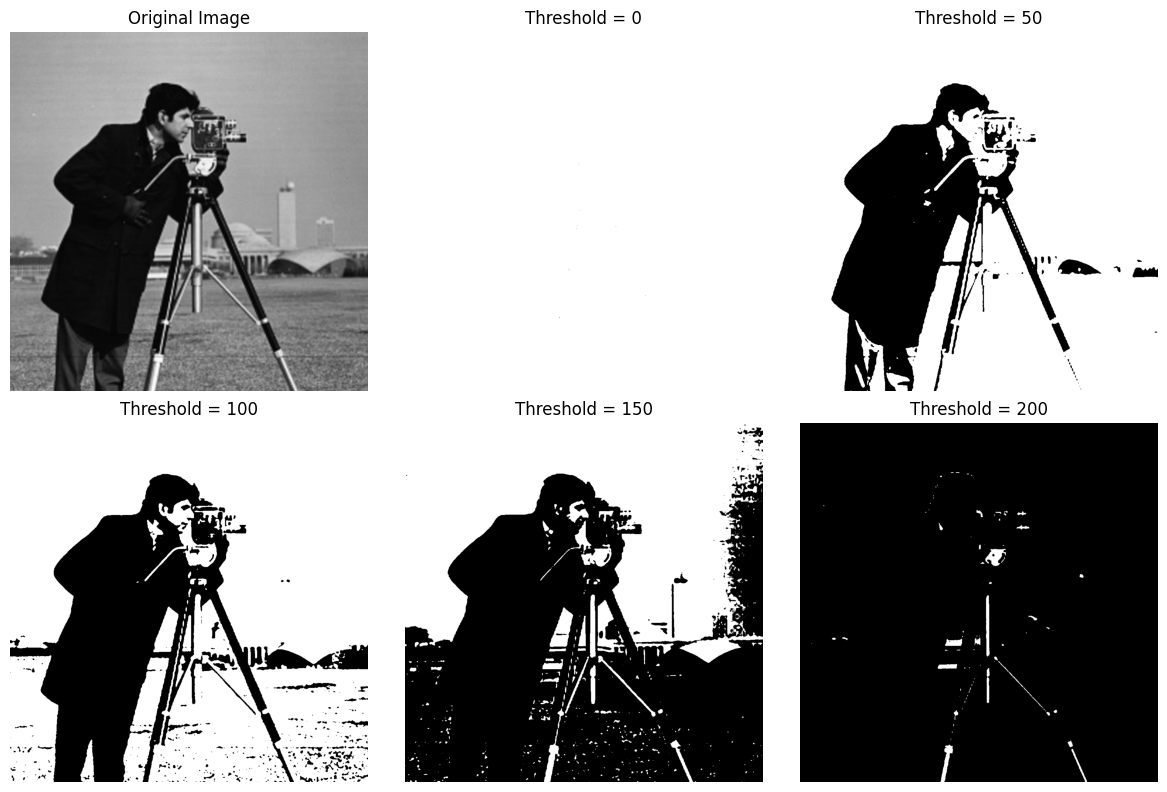

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure
from skimage.exposure import match_histograms

# Load the provided cameraman image in grayscale.
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(
        "cameraman.png was not found. Put cameraman.png in the same folder as this notebook."
    )

# Set the threshold values.
threshold_values = [0, 50, 100, 150, 200]

# Display original image and thresholded results.
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image')
axes[0].axis('off')

for i, threshold_value in enumerate(threshold_values, start=1):
    _, thresh_img = cv2.threshold(
        img, threshold_value, 255, cv2.THRESH_BINARY
    )

    axes[i].imshow(thresh_img, cmap='gray', vmin=0, vmax=255)
    axes[i].set_title(f'Threshold = {threshold_value}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


## 2. Histogram Processing — Example

/opt/pyvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


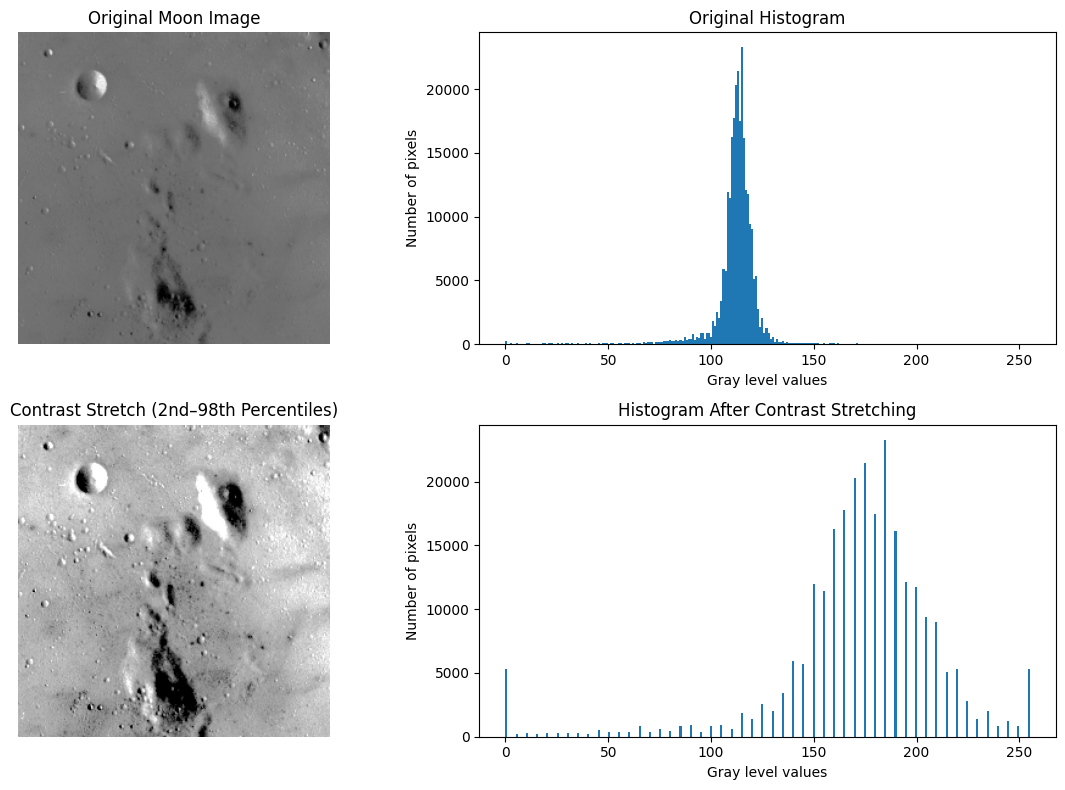

In [2]:
# Load the moon image.
moon = data.moon()

# Contrast stretching using the 2nd and 98th percentiles.
p2, p98 = np.percentile(moon, (2, 98))
moon_rescale = exposure.rescale_intensity(moon, in_range=(p2, p98))

# Display original and contrast-stretched images with their histograms.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(moon, cmap='gray')
axes[0, 0].set_title('Original Moon Image')
axes[0, 0].axis('off')

axes[0, 1].hist(moon.ravel(), bins=256, range=(0, 255))
axes[0, 1].set_title('Original Histogram')
axes[0, 1].set_xlabel('Gray level values')
axes[0, 1].set_ylabel('Number of pixels')

axes[1, 0].imshow(moon_rescale, cmap='gray')
axes[1, 0].set_title('Contrast Stretch (2nd–98th Percentiles)')
axes[1, 0].axis('off')

axes[1, 1].hist(moon_rescale.ravel(), bins=256, range=(0, 255))
axes[1, 1].set_title('Histogram After Contrast Stretching')
axes[1, 1].set_xlabel('Gray level values')
axes[1, 1].set_ylabel('Number of pixels')

plt.tight_layout()
plt.show()


# Required Tasks

### Task 1
Using the same **moon image**, rescale intensity values to include all intensities that fall within the **3rd and 80th percentiles**, then plot the histogram.


3rd percentile intensity  = 87.00
80th percentile intensity = 118.00


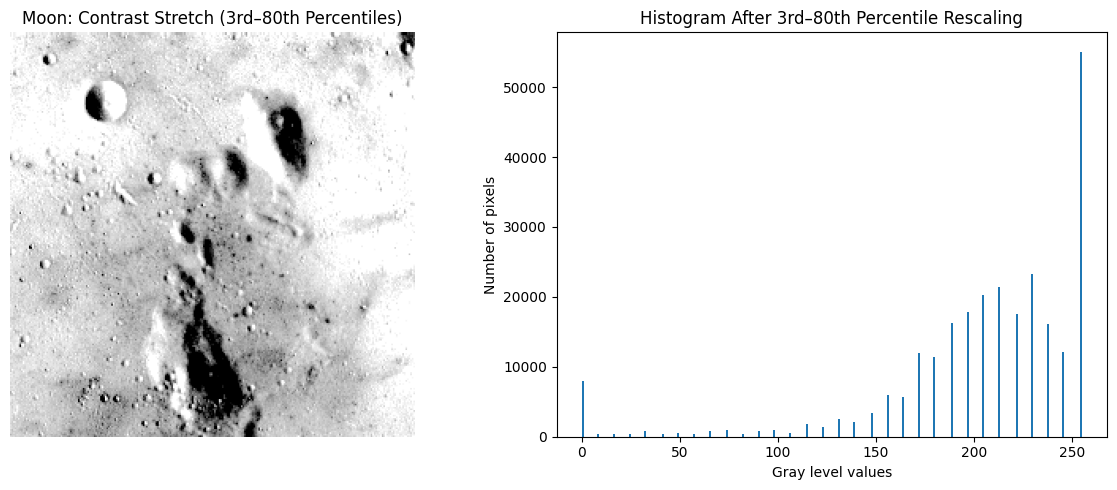

In [3]:
# Task 1: Contrast stretching using the 3rd and 80th percentiles.

moon = data.moon()

# Calculate the required percentile intensity values.
p3, p80 = np.percentile(moon, (3, 80))

print(f'3rd percentile intensity  = {p3:.2f}')
print(f'80th percentile intensity = {p80:.2f}')

# Rescale image intensities.
moon_rescale_3_80 = exposure.rescale_intensity(
    moon,
    in_range=(p3, p80)
)

# Display image and histogram.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(moon_rescale_3_80, cmap='gray')
axes[0].set_title('Moon: Contrast Stretch (3rd–80th Percentiles)')
axes[0].axis('off')

axes[1].hist(
    moon_rescale_3_80.ravel(),
    bins=256,
    range=(0, 255)
)
axes[1].set_title('Histogram After 3rd–80th Percentile Rescaling')
axes[1].set_xlabel('Gray level values')
axes[1].set_ylabel('Number of pixels')

plt.tight_layout()
plt.show()


### Task 2
Using the same **moon image** and `exposure.equalize_hist`, display the image and its histogram after histogram equalization.


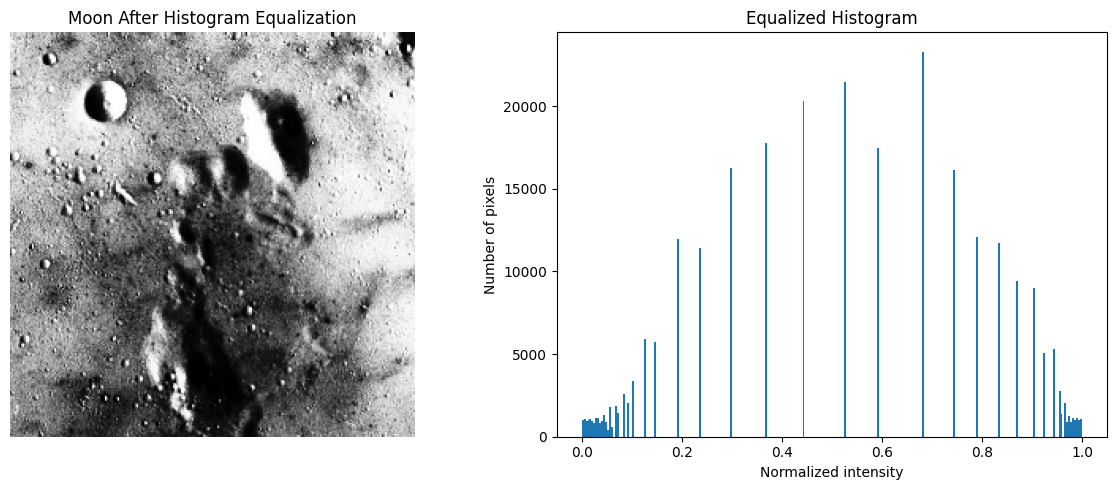

In [4]:
# Task 2: Histogram equalization.

moon = data.moon()

# equalize_hist returns a floating-point image with values in [0, 1].
moon_equalized = exposure.equalize_hist(moon)

# Display equalized image and histogram.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(moon_equalized, cmap='gray')
axes[0].set_title('Moon After Histogram Equalization')
axes[0].axis('off')

axes[1].hist(
    moon_equalized.ravel(),
    bins=256,
    range=(0, 1)
)
axes[1].set_title('Equalized Histogram')
axes[1].set_xlabel('Normalized intensity')
axes[1].set_ylabel('Number of pixels')

plt.tight_layout()
plt.show()


### Task 3
Use the **rocket image as the reference** and the **chelsea image as the source**, then implement histogram matching.


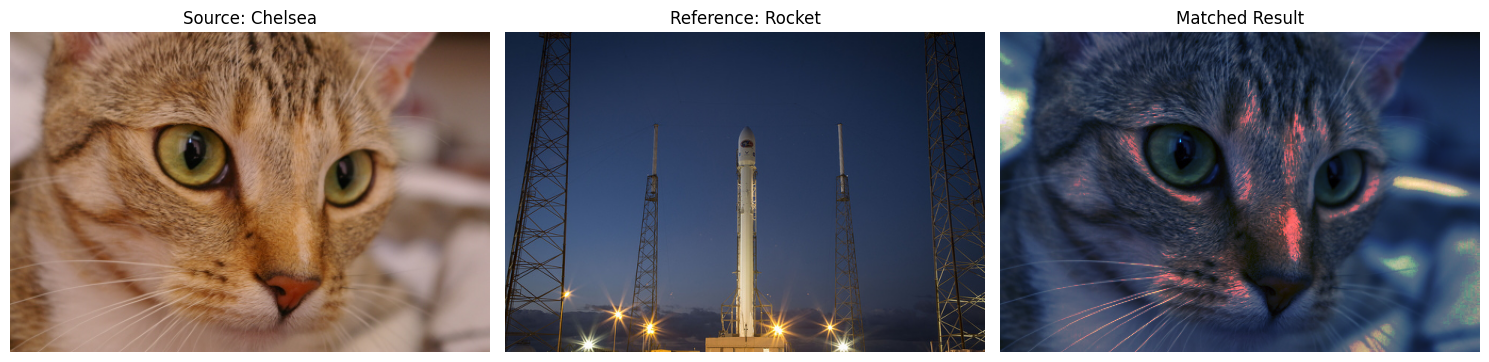

In [5]:
# Task 3: Histogram matching.
# Source image    = chelsea
# Reference image = rocket

source = data.chelsea()
reference = data.rocket()

# Match the color distribution of Chelsea to the Rocket image.
matched = match_histograms(
    source,
    reference,
    channel_axis=-1
)

# Display source, reference, and matched images.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(source)
axes[0].set_title('Source: Chelsea')
axes[0].axis('off')

axes[1].imshow(reference)
axes[1].set_title('Reference: Rocket')
axes[1].axis('off')

axes[2].imshow(np.clip(matched, 0, 255).astype(np.uint8))
axes[2].set_title('Matched Result')
axes[2].axis('off')

plt.tight_layout()
plt.show()


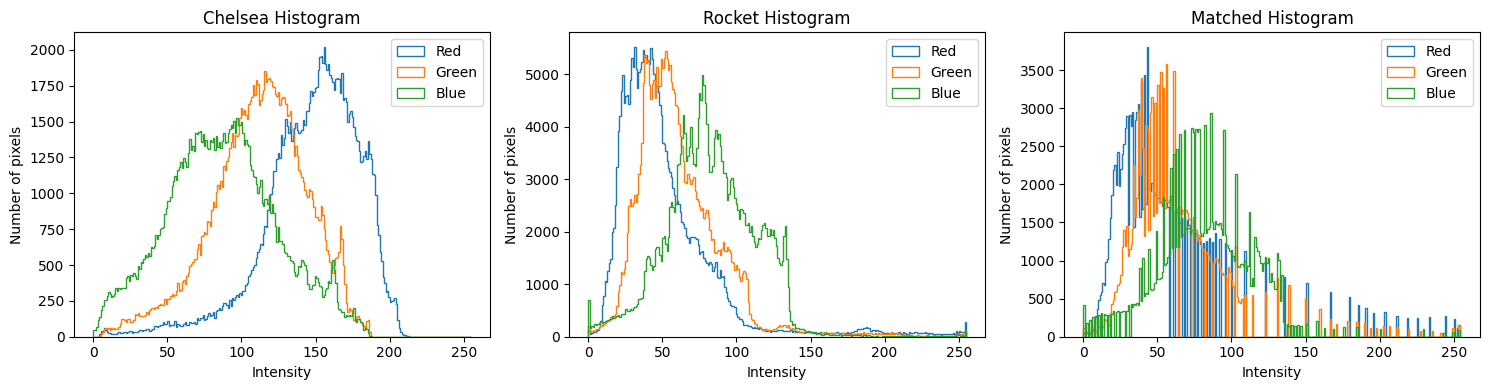

In [6]:
# Plot RGB histograms to compare the source, reference, and matched result.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

images = [source, reference, matched]
titles = ['Chelsea Histogram', 'Rocket Histogram', 'Matched Histogram']
channel_names = ['Red', 'Green', 'Blue']

for ax, image, title in zip(axes, images, titles):
    for channel in range(3):
        values = image[..., channel].ravel()
        ax.hist(
            values,
            bins=256,
            range=(0, 255),
            histtype='step',
            label=channel_names[channel]
        )
    ax.set_title(title)
    ax.set_xlabel('Intensity')
    ax.set_ylabel('Number of pixels')
    ax.legend()

plt.tight_layout()
plt.show()


## Short Answers / Observations

- **Task 1:** Using the 3rd and 80th percentiles stretches the selected intensity range and increases visible contrast in the moon image.
- **Task 2:** Histogram equalization redistributes intensity values so that the histogram becomes more spread out, which generally improves global contrast.
- **Task 3:** Histogram matching changes the intensity/color distribution of the Chelsea image so it becomes statistically closer to the Rocket reference image while keeping Chelsea's spatial content.
